# Retail Business Performance

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

df = pd.read_csv('../data/cleaned/superstore_cleaned_python.csv', parse_dates=['Order Date', 'Ship Date'])
df.shape

(9993, 26)

## Overview

In [4]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product Name,Sales,Quantity,Discount,Profit,Profit Margin,Order Year,Order Month,Shipping Days,Discount Band
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91,0.16,2016,11,3,No Discount
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58,0.30,2016,11,3,No Discount
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87,0.47,2016,6,4,No Discount
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03,-0.40,2015,10,7,High (40%+)
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52,0.11,2015,10,7,Low (1-20%)


In [5]:
df[['Sales', 'Profit', 'Discount', 'Quantity', 'Profit Margin']].describe()

,Sales,Profit,Discount,Quantity,Profit Margin
count,"9,993.00","9,993.00","9,993.00","9,993.00","9,993.00"
mean,229.85,28.66,0.16,3.79,0.12
std,623.28,234.27,0.21,2.23,0.47
min,0.44,"-6,599.98",0.00,1.00,-2.75
25%,17.28,1.73,0.00,2.00,0.07
50%,54.48,8.67,0.20,3.00,0.27
75%,209.94,29.36,0.20,5.00,0.36
max,"22,638.48","8,399.98",0.80,14.00,0.50


## Sales and profit trend over time

C:\Users\dunit\AppData\Local\Temp\ipykernel_21588\1738239229.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df.set_index('Order Date').resample('M')[['Sales', 'Profit']].sum()


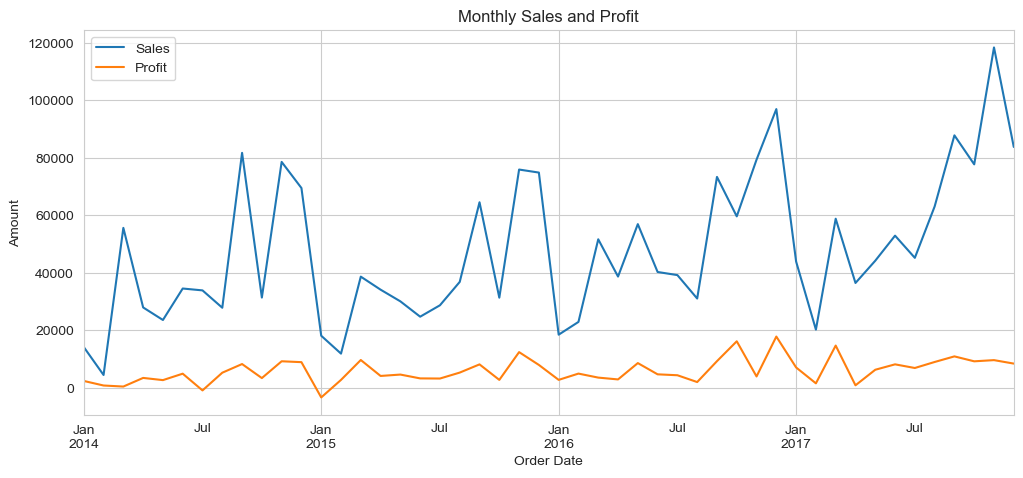

In [6]:
monthly = df.set_index('Order Date').resample('M')[['Sales', 'Profit']].sum()

fig, ax = plt.subplots(figsize=(12, 5))
monthly['Sales'].plot(ax=ax, label='Sales')
monthly['Profit'].plot(ax=ax, label='Profit')
ax.set_title('Monthly Sales and Profit')
ax.set_ylabel('Amount')
ax.legend()
plt.show()

## Sales and profit by region

In [7]:
region_summary = df.groupby('Region')[['Sales', 'Profit']].sum().sort_values('Sales', ascending=False)
region_summary['Profit Margin %'] = (region_summary['Profit'] / region_summary['Sales']) * 100
region_summary

,Sales,Profit,Profit Margin %
Region,,,
West,"725,457.82","108,418.45",14.94
East,"678,499.87","91,534.84",13.49
Central,"501,239.89","39,706.36",7.92
South,"391,721.91","46,749.43",11.93


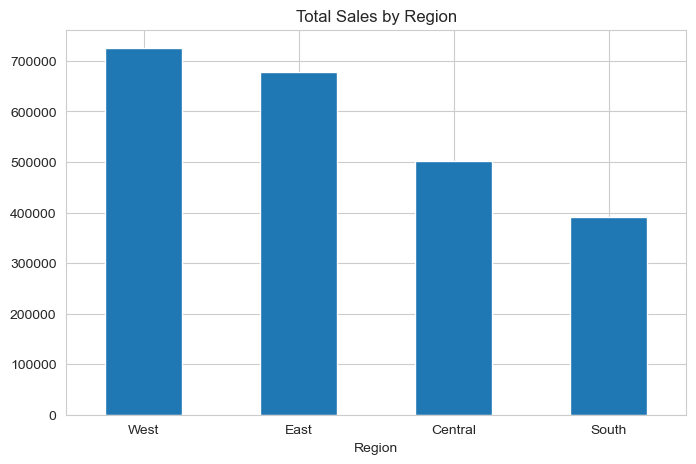

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
region_summary['Sales'].plot(kind='bar', ax=ax, color='#1f77b4')
ax.set_title('Total Sales by Region')
plt.xticks(rotation=0)
plt.show()

## Sales and profit by category/sub category

In [14]:
category_summary = df.groupby('Category')[['Sales', 'Profit']].sum().sort_values('Sales', ascending=False)
category_summary

,Sales,Profit
Category,,
Technology,"836,154.03","145,454.95"
Furniture,"741,718.42","18,463.33"
Office Supplies,"719,047.03","122,490.80"


In [15]:
subcat_summary = df.groupby('Sub-Category')[['Sales', 'Profit']].sum().sort_values('Profit')
subcat_summary

,Sales,Profit
Sub-Category,,
Tables,"206,965.53","-17,725.48"
Bookcases,"114,880.00","-3,472.56"
Supplies,"46,673.54","-1,189.10"
Fasteners,"3,024.28",949.52
Machines,"189,238.63","3,384.76"
Labels,"12,486.31","5,546.25"
Art,"27,118.79","6,527.79"
Envelopes,"16,476.40","6,964.18"
Furnishings,"91,705.16","13,059.14"


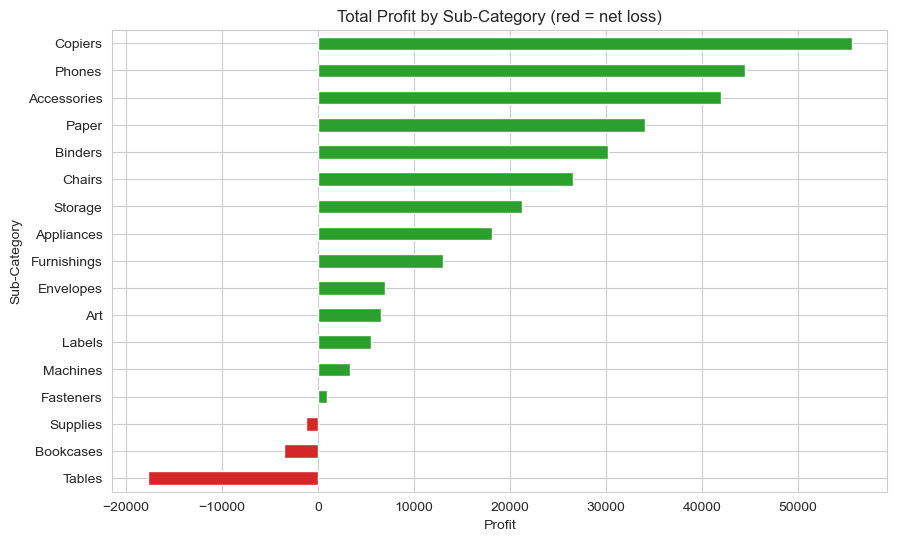

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#d62728' if v < 0 else '#2ca02c' for v in subcat_summary['Profit']]
subcat_summary['Profit'].plot(kind='barh', ax=ax, color=colors)
ax.set_title('Total Profit by Sub-Category (red = net loss)')
ax.set_xlabel('Profit')
plt.show()

## Discount impact on profit

In [17]:
band_order = ['No Discount', 'Low (1-20%)', 'Medu=ium (21%-40%)', 'Hight (40%+)']
discount_band_summary = df.groupby('Discount Band')['Profit'].sum().reindex(band_order)
discount_band_summary

Discount Band
No Discount          320,987.60
Low (1-20%)          100,785.47
Medu=ium (21%-40%)          NaN
Hight (40%+)                NaN
Name: Profit, dtype: float64

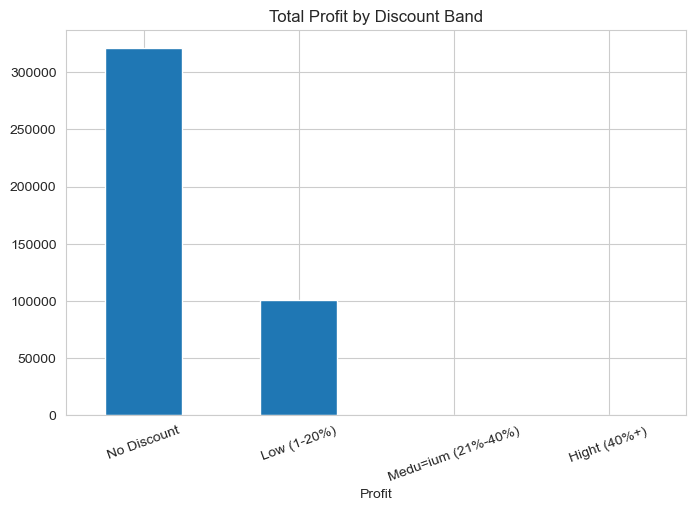

In [22]:
fig, ax = plt.subplots(figsize=(8, 5))
discount_band_summary.plot(kind='bar', ax=ax, color='#1f77b4')
ax.set_title('Total Profit by Discount Band')
ax.set_xlabel('Profit')
plt.xticks(rotation=20)
plt.show()

In [23]:
discount_by_subcat = df.groupby('Sub-Category').agg(
    avg_discount=('Discount', 'mean'),
    total_profit=('Profit', 'sum')
).sort_values('total_profit')

discount_by_subcat.head(10)

,avg_discount,total_profit
Sub-Category,,
Tables,0.26,"-17,725.48"
Bookcases,0.21,"-3,472.56"
Supplies,0.08,"-1,189.10"
Fasteners,0.08,949.52
Machines,0.31,"3,384.76"
Labels,0.07,"5,546.25"
Art,0.07,"6,527.79"
Envelopes,0.08,"6,964.18"
Furnishings,0.14,"13,059.14"


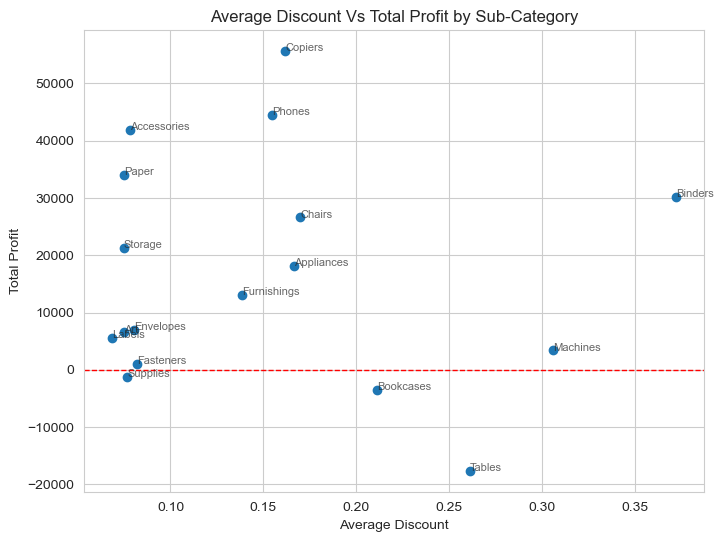

In [24]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(discount_by_subcat['avg_discount'], discount_by_subcat['total_profit'])
for name, row in discount_by_subcat.iterrows():
    ax.annotate(name, (row['avg_discount'], row['total_profit']), fontsize=8, alpha=0.7)
ax.axhline(0, color='red', linestyle='--', linewidth=1)
ax.set_xlabel('Average Discount')
ax.set_ylabel('Total Profit')
ax.set_title('Average Discount Vs Total Profit by Sub-Category')
plt.show()

## Correlation Check

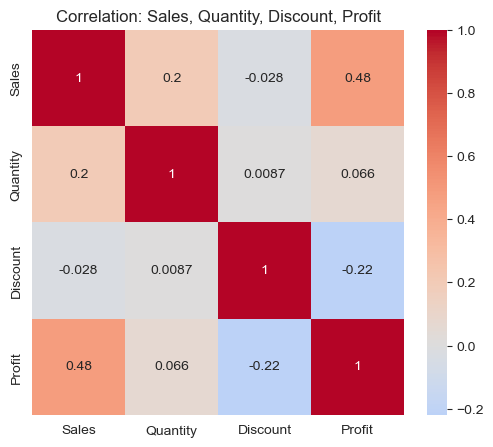

In [27]:
corr_cols = ['Sales', 'Quantity', 'Discount', 'Profit']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation: Sales, Quantity, Discount, Profit')
plt.show()